In [1]:
# 需要的列
col_hf = ['OPEN', 'HIGH', 'LOW', 'CLOSE', 'VOLUME']
col_lf = ['FA_ROE_AVG', 'FA_ORGR_TTM', 'FA_DEBTTOASSET', "PE_TTM","WEST_SALES_FTM_CHG_3M", "WEST_NETPROFIT_FTM_CHG_3M"]
target = 'target_return'

In [17]:
# 读取数据
import pandas as pd
df_cleaned = pd.read_parquet('data/cleaned_300.parquet')
df_cleaned = df_cleaned.dropna(subset=[target])
print(df_cleaned.head(5))
print(len(df_cleaned))

        date  WEST_NETPROFIT_FY1_CHG_3M  WEST_NETPROFIT_FTM_CHG_3M  \
0 2016-01-29              -6.002894e+07                   0.182098   
1 2016-02-01              -6.002894e+07                   0.183956   
2 2016-02-02              -6.002894e+07                   0.184575   
3 2016-02-03              -6.002894e+07                   0.185194   
4 2016-02-04              -6.002894e+07                   0.185813   

   WEST_SALES_FY1_3M  WEST_SALES_FTM_CHG_3M  VAL_AVGPE_SW    PE_TTM  \
0           0.599239               0.260246        6.1239 -0.473854   
1           0.599239               0.260712        6.0169 -0.475900   
2           0.599239               0.260868        6.0808 -0.474365   
3           0.599239               0.261023        6.0249 -0.475389   
4           0.599239               0.261179        6.0988 -0.474365   

   VAL_STDPE_SW  DFA_TLTSHARE  FA_ROE_AVG  ...  FA_CTOP       code  \
0        0.7118  1.430868e+10    0.708562  ...      NaN  000001.SZ   
1        0.7

count    627075.000000
mean          0.000739
std           0.024615
min          -0.200177
25%          -0.011111
50%           0.000000
75%           0.010704
max           0.200420
Name: target_return, dtype: float64


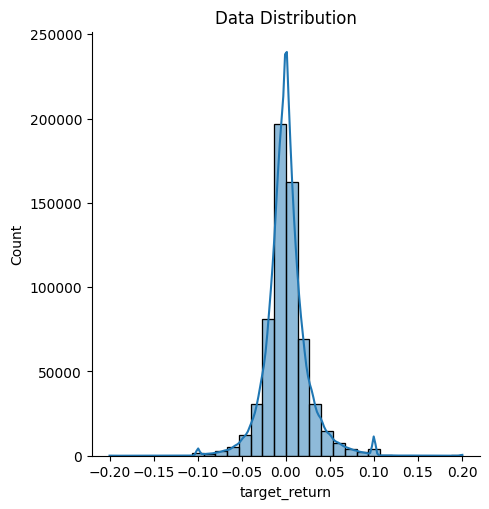

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# 假设你的 dataframe 叫 df，想看其中的 'column_name' 列
df_filtered = df_cleaned[df_cleaned['target_return'] < df_cleaned['target_return'].max()]
sns.displot(df_filtered['target_return'], kde=True, bins=30)
stats = df_filtered['target_return'].describe()
print(stats)
plt.title('Data Distribution')
plt.show()

In [ ]:
# 切分训练集和测试集
# 确保 date 列是 datetime 格式
df_cleaned['date'] = pd.to_datetime(df_cleaned['date'])
# 获取所有交易日并排序
all_dates = df_cleaned['date'].sort_values().unique()
# 计算分割点的索引
train_split_idx = int(len(all_dates) * 0.85)
# 得到具体的分割日期
train_end_date = all_dates[train_split_idx]


print(f"训练集期间: 开始 到 {train_end_date.strftime('%Y-%m-%d')}")
print(f"验证集期间: {train_end_date.strftime('%Y-%m-%d')} 到 结束")


# 按日期切分 DataFrame
df_train = df_cleaned[df_cleaned['date'] < train_end_date].copy()
df_val = df_cleaned[df_cleaned['date'] >= train_end_date].copy()

训练集期间: 开始 到 2024-08-16
验证集期间: 2024-08-16 到 结束


In [16]:
print(df_val.head(5))

           date  WEST_NETPROFIT_FY1_CHG_3M  WEST_NETPROFIT_FTM_CHG_3M  \
2078 2024-08-19              -8.581538e+07                  -0.045600   
2079 2024-08-20              -8.581538e+07                  -0.045909   
2080 2024-08-21              -8.581538e+07                  -0.046217   
2081 2024-08-22              -8.581538e+07                  -0.046526   
2082 2024-08-23              -8.581538e+07                  -0.046835   

      WEST_SALES_FY1_3M  WEST_SALES_FTM_CHG_3M  VAL_AVGPE_SW    PE_TTM  \
2078          -2.982353              -0.722008        5.3436 -0.509721   
2079          -2.982353              -0.722383        5.3395 -0.509398   
2080          -2.982353              -0.722758        5.2805 -0.509333   
2081          -2.982353              -0.723133        5.3281 -0.509139   
2082          -2.982353              -0.723508        5.3253 -0.508558   

      VAL_STDPE_SW  DFA_TLTSHARE  FA_ROE_AVG  ...   FA_CTOP       code  \
2078        1.0241  1.940592e+10   -0.2611

In [19]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np

class QuantDataset(Dataset):
    def __init__(self, df, col_hf, col_lf, target, window_size=20):
        # 1. 确保数据按股票和时间排序，这是滑动窗口的基础
        df = df.sort_values(['code', 'date'])
        
        # 2. 将数据转换为 numpy 数组提高索引速度
        self.hf_data = df[col_hf].values.astype(np.float32)
        self.lf_data = df[col_lf].values.astype(np.float32)
        self.targets = df[target].values.astype(np.float32)
        
        # 3. 记录每只股票的索引范围，防止滑动窗口跨越两只不同的股票
        self.valid_indices = []
        codes = df['code'].values
        # 找到每只股票开始的索引位置
        _, start_indices = np.unique(codes, return_index=True)
        end_indices = np.append(start_indices[1:], len(df))
        
        for start, end in zip(start_indices, end_indices):
            # 只有长度大于窗口大小的股票才有有效窗口
            if end - start >= window_size:
                # 记录该股票下所有可用的结束位置索引
                for i in range(start + window_size - 1, end):
                    self.valid_indices.append(i)
        
        self.window_size = window_size

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        # 获取当前样本在原始 DataFrame 中的实际索引位置
        actual_idx = self.valid_indices[idx]
        
        # 高频特征：取过去 window_size 天的序列 (T, F)
        x_hf = self.hf_data[actual_idx - self.window_size + 1 : actual_idx + 1]
        
        # 低频特征：只取当前时刻 (F,)
        x_lf = self.lf_data[actual_idx]
        
        # 标签
        y = self.targets[actual_idx]
        
        return torch.from_numpy(x_hf), torch.from_numpy(x_lf), torch.tensor([y])

In [20]:
# 实例化数据集
train_dataset = QuantDataset(df_train, col_hf, col_lf, target, window_size=20)
val_dataset = QuantDataset(df_val, col_hf, col_lf, target, window_size=20)

# 创建 DataLoader
# shuffle=True 仅在训练集使用，打破时序相关性有助于模型泛化
train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=1024, shuffle=False, num_workers=0)

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class QuantHybridModel(nn.Module):
    def __init__(self, hf_input_dim=5, lf_input_dim=6, window_size=20, hidden_dim=128):
        super(QuantHybridModel, self).__init__()
        
        # ====================
        # 分支 1: 高频时序网络
        # ====================
        #  CNN 层 (提取局部特征，如 3 天内的 K 线组合)
        # 输入 (Batch, Channels, Length) -> PyTorch Conv1d 要求通道在中间
        self.conv = nn.Conv1d(in_channels=hf_input_dim, out_channels=32, kernel_size=3, padding=0)
        
        #  LSTM 层
        self.lstm = nn.LSTM(input_size=32, hidden_size=hidden_dim, num_layers=1, batch_first=True)
        
        
        # ====================
        # 分支 2: 低频基本面网络
        # ====================
        # MLP 层
        self.mlp = nn.Sequential(
            nn.Linear(lf_input_dim, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16)
        )
        

        # 3. Attention 层
        combined_dim = hidden_dim + 16 # 128 + 16 = 144
        self.attn_weights = nn.Sequential(
            nn.Linear(combined_dim, combined_dim),
            nn.ReLU(),
            nn.Linear(combined_dim, combined_dim),
            nn.Sigmoid() # 使用 Sigmoid 阀门控制每个特征的去留
        )


        # ====================
        # 融合层 (Fusion)
        # ====================
        # 将 Attention的上下文向量 (hidden_dim) 和 MLP输出 (16) 拼接
        self.fc = nn.Sequential(
            nn.BatchNorm1d(hidden_dim + 16),
            nn.Linear(hidden_dim + 16, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1) # 最终预测下一期收益率
        )
        self.post_attn_dropout = nn.Dropout(0.3)

    def forward(self, x_hf, x_lf):
        # --- 高频分支前向传播 ---
        # x_hf 初始形状: (Batch, Seq_len, Features) -> (B, 20, 5)
        # 适应 Conv1d 转换为: (Batch, Features, Seq_len) -> (B, 5, 20)
        x_hf = x_hf.permute(0, 2, 1) 
        x_hf = F.relu(self.conv(x_hf))
        
        # 适应 LSTM 再转回: (Batch, Seq_len, Conv_out) -> (B, 20, 32)
        x_hf = x_hf.permute(0, 2, 1)
        lstm_out, _ = self.lstm(x_hf) # lstm_out: (B, 20, 128)
        
        # 输出高频特征
        hf_feature = lstm_out[:, -1, :]

        # --- 低频分支前向传播 ---
        # x_lf 形状: (Batch, Features) -> (B, 6)
        lf_feature = self.mlp(x_lf) # 输出: (B, 16)
       
        # --- 特征融合与输出 ---
        # 形状变化: (B, 128) + (B, 16) -> (B, 80)
        combined = torch.cat((hf_feature, lf_feature), dim=1)
        # 计算全局权重 (B, 80) -> (B, 80)
        # 这里 self.attn_weights 需要重新定义，输入输出维度都是 80
        attn_scores = self.attn_weights(combined) 
        attn_weights = torch.sigmoid(attn_scores) # 或者 Softmax，看你想让它们竞争还是独立
        
        # 元素级加权
        weighted_combined = combined * attn_weights
        weighted_combined = self.post_attn_dropout(weighted_combined)
        # --- 4. 最终输出 ---
        output = self.fc(weighted_combined)
        return output
    
# 实例化模型
model = QuantHybridModel(hf_input_dim=len(col_hf), lf_input_dim=len(col_lf))
print(model)

QuantHybridModel(
  (conv): Conv1d(5, 32, kernel_size=(3,), stride=(1,))
  (lstm): LSTM(32, 128, batch_first=True)
  (mlp): Sequential(
    (0): Linear(in_features=6, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=32, out_features=16, bias=True)
  )
  (attn_weights): Sequential(
    (0): Linear(in_features=144, out_features=144, bias=True)
    (1): ReLU()
    (2): Linear(in_features=144, out_features=144, bias=True)
    (3): Sigmoid()
  )
  (fc): Sequential(
    (0): BatchNorm1d(144, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (1): Linear(in_features=144, out_features=32, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
  (post_attn_dropout): Dropout(p=0.3, inplace=False)
)


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import numpy as np
from scipy.stats import spearmanr # 用于计算相关系数

# 1. 配置设备与超参数
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=5e-5, weight_decay=1e-5)
epochs = 40
best_val_ric = -1
patience = 10  # 连续10轮不进步就“放学”
counter = 0
from scipy.stats import spearmanr

def compute_rank_ic(y_pred, y_true):
    # spearmanr 返回 (correlation, p-value)
    return float(spearmanr(y_pred, y_true).correlation) # type: ignore

# 定义 Loss 函数，margin 建议设在 0.01 到 0.1 之间
criterion_pairwise = nn.MarginRankingLoss(margin=0.01)

# 在训练循环中改写计算方式
def compute_pairwise_loss(outputs, batch_y):
    # 假设 outputs 和 batch_y 的 shape 都是 [batch_size]
    # 我们构造“两两对子”：将原始序列平移一个位置
    out_i = outputs[:-1]
    out_j = outputs[1:]
    
    y_i = batch_y[:-1]
    y_j = batch_y[1:]
    
    # 目标：如果 y_i > y_j，target 为 1；如果 y_i < y_j，target 为 -1
    target = torch.sign(y_i - y_j)
    
    # 过滤掉 y_i == y_j 的情况（虽然在收益率数据中很少见）
    mask = target != 0
    return criterion_pairwise(out_i[mask], out_j[mask], target[mask])


# 记录过程
history = {'train_loss': [], 'train_rank_ic': [], 'val_loss': [], 'val_rank_ic': []}

for epoch in range(epochs):
    # ================= 训练阶段 =================
    model.train()
    train_losses, train_preds, train_targets = [], [], []
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
    for batch_hf, batch_lf, batch_y in pbar:
        batch_hf, batch_lf, batch_y = batch_hf.to(device), batch_lf.to(device), batch_y.to(device)
        
        outputs = model(batch_hf, batch_lf)
        loss = compute_pairwise_loss(outputs.view(-1), batch_y.view(-1))
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_losses.append(loss.item())
        train_preds.append(outputs.detach().cpu().numpy())
        train_targets.append(batch_y.detach().cpu().numpy())

    y_train_true = np.concatenate(train_targets).flatten()
    y_train_pred = np.concatenate(train_preds).flatten()
    train_ric = compute_rank_ic(y_train_pred, y_train_true)
    
    # ================= 验证阶段 =================
    model.eval()
    val_losses, val_preds, val_targets = [], [], []
    
    with torch.no_grad():
        for batch_hf, batch_lf, batch_y in val_loader:
            batch_hf, batch_lf, batch_y = batch_hf.to(device), batch_lf.to(device), batch_y.to(device)
            outputs = model(batch_hf, batch_lf)
            val_losses.append(criterion(outputs, batch_y).item())
            val_preds.append(outputs.cpu().numpy())
            val_targets.append(batch_y.cpu().numpy())
            
    y_val_true = np.concatenate(val_targets).flatten()
    y_val_pred = np.concatenate(val_preds).flatten()
    val_ric = compute_rank_ic(y_val_pred, y_val_true)
    
    print(f"Epoch {epoch+1}: Train RankIC: {train_ric:.4f} | Val RankIC: {val_ric:.4f} | Val Loss: {np.mean(val_losses):.6f}")
    
    
    # 验证逻辑结束后：
    if val_ric > best_val_ric:
        best_val_ric = val_ric
        torch.save(model.state_dict(), 'best_model_ever.pth') # 存下成绩最好的时刻
        print(f"--- 💡 发现最佳表现: {val_ric:.4f}, 已存盘 ---")
        counter = 0 # 重置计数器
    else:
        counter += 1
        
    if counter >= patience:
        print(f"--- 🛑 娃学不动了，早停在 Epoch {epoch+1} ---")
        break

Epoch 1/40 [Train]: 100%|██████████| 1009/1009 [00:35<00:00, 28.27it/s]


Epoch 1: Train RankIC: 0.0018 | Val RankIC: 0.0031 | Val Loss: 0.005355
--- 💡 发现最佳表现: 0.0031, 已存盘 ---


Epoch 2/40 [Train]: 100%|██████████| 1009/1009 [00:35<00:00, 28.30it/s]


Epoch 2: Train RankIC: 0.0007 | Val RankIC: 0.0085 | Val Loss: 0.001889
--- 💡 发现最佳表现: 0.0085, 已存盘 ---


Epoch 3/40 [Train]: 100%|██████████| 1009/1009 [00:37<00:00, 26.84it/s]


...

Epoch 23: Train RankIC: 0.0575 | Val RankIC: 0.0259 | Val Loss: 0.000648


Epoch 24/40 [Train]: 100%|██████████| 1009/1009 [00:37<00:00, 26.68it/s]


Epoch 24: Train RankIC: 0.0571 | Val RankIC: 0.0238 | Val Loss: 0.000648


Epoch 25/40 [Train]: 100%|██████████| 1009/1009 [00:38<00:00, 26.26it/s]


Epoch 25: Train RankIC: 0.0596 | Val RankIC: 0.0274 | Val Loss: 0.000647
--- 🛑 娃学不动了，早停在 Epoch 25 ---
